In [44]:
# Import pandas
import pandas as pd

# Load dataset from the same folder as notebook
df = pd.read_csv("investment_product_subscription_dataset.xls")

# Display first 5 rows
df.head()

,Customer_ID,Age,Employment_Status,Annual_Income,Account_Balance,Risk_Tolerance,Previous_Investments,Advisor_Contacted,Mobile_Banking_User,Financial_Literacy_Score,Marketing_Email_Opened,Number_of_Bank_Products,Subscribed_Investment_Product
0,1,28.0,Part-time,189900.0,185575.0,Medium,No,Yes,Yes,3,Yes,7,Yes
1,2,61.0,Self-employed,57470.0,184258.0,Low,No,Yes,Yes,3,NaN,2,No
2,3,27.0,Student,27164.0,50417.0,Medium,No,Yes,Yes,6,No,1,Yes
3,4,35.0,Student,112229.0,182140.0,Low,No,No,Yes,9,No,5,No
4,5,76.0,Student,149913.0,160977.0,High,Yes,Yes,Yes,1,Yes,1,Yes


In [45]:
# Define the target column that we want to predict
target_column = "Subscribed_Investment_Product"

# Print the target column name
print("Target column:")
print(target_column)

# Count how many Yes and No values are in the target column
print("\nTarget values:")
print(df[target_column].value_counts())

Target column:
Subscribed_Investment_Product

Target values:
Subscribed_Investment_Product
Yes    198
No     179
Name: count, dtype: int64


In [46]:
# Display the first five rows of the dataset
df.head()

,Customer_ID,Age,Employment_Status,Annual_Income,Account_Balance,Risk_Tolerance,Previous_Investments,Advisor_Contacted,Mobile_Banking_User,Financial_Literacy_Score,Marketing_Email_Opened,Number_of_Bank_Products,Subscribed_Investment_Product
0,1,28.0,Part-time,189900.0,185575.0,Medium,No,Yes,Yes,3,Yes,7,Yes
1,2,61.0,Self-employed,57470.0,184258.0,Low,No,Yes,Yes,3,NaN,2,No
2,3,27.0,Student,27164.0,50417.0,Medium,No,Yes,Yes,6,No,1,Yes
3,4,35.0,Student,112229.0,182140.0,Low,No,No,Yes,9,No,5,No
4,5,76.0,Student,149913.0,160977.0,High,Yes,Yes,Yes,1,Yes,1,Yes


In [47]:
# Print the number of rows and columns in the dataset
print("Dataset shape:")
print(df.shape)

Dataset shape:
(377, 13)


In [48]:
# Print all column names as a list
print("Column names:")
print(df.columns.tolist())

Column names:
['Customer_ID', 'Age', 'Employment_Status', 'Annual_Income', 'Account_Balance', 'Risk_Tolerance', 'Previous_Investments', 'Advisor_Contacted', 'Mobile_Banking_User', 'Financial_Literacy_Score', 'Marketing_Email_Opened', 'Number_of_Bank_Products', 'Subscribed_Investment_Product']


In [49]:
# Show general information about the dataset
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    377 non-null    int64  
 1   Age                            370 non-null    float64
 2   Employment_Status              370 non-null    object 
 3   Annual_Income                  370 non-null    float64
 4   Account_Balance                370 non-null    float64
 5   Risk_Tolerance                 370 non-null    object 
 6   Previous_Investments           377 non-null    object 
 7   Advisor_Contacted              377 non-null    object 
 8   Mobile_Banking_User            377 non-null    object 
 9   Financial_Literacy_Score       377 non-null    int64  
 10  Marketing_Email_Opened         370 non-null    object 
 11  Number_of_Bank_Products        377 non-null    int64  
 12  Subscribed_Investment_Product

In [50]:
# Print the data type of each column
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
Customer_ID                        int64
Age                              float64
Employment_Status                 object
Annual_Income                    float64
Account_Balance                  float64
Risk_Tolerance                    object
Previous_Investments              object
Advisor_Contacted                 object
Mobile_Banking_User               object
Financial_Literacy_Score           int64
Marketing_Email_Opened            object
Number_of_Bank_Products            int64
Subscribed_Investment_Product     object
dtype: object


In [51]:
# Count missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Customer_ID                      0
Age                              7
Employment_Status                7
Annual_Income                    7
Account_Balance                  7
Risk_Tolerance                   7
Previous_Investments             0
Advisor_Contacted                0
Mobile_Banking_User              0
Financial_Literacy_Score         0
Marketing_Email_Opened           7
Number_of_Bank_Products          0
Subscribed_Investment_Product    0
dtype: int64


In [52]:
# Count duplicate rows in the dataset
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
7


In [53]:
# Create a copy of the original dataset
df_clean = df.copy()

# Print the original dataset shape
print("Original dataset shape:")
print(df_clean.shape)

# Print the number of duplicate rows before cleaning
print("\nNumber of duplicate rows before cleaning:")
print(df_clean.duplicated().sum())

Original dataset shape:
(377, 13)

Number of duplicate rows before cleaning:
7


In [54]:
# Remove duplicate rows from the dataset
df_clean = df_clean.drop_duplicates()

# Reset the index after removing duplicates
df_clean = df_clean.reset_index(drop=True)

# Print the dataset shape after removing duplicates
print("Dataset shape after removing duplicate rows:")
print(df_clean.shape)

# Print the number of duplicate rows after cleaning
print("\nNumber of duplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Dataset shape after removing duplicate rows:
(370, 13)

Number of duplicate rows after cleaning:
0


In [55]:
# Count missing values before filling them
print("Missing values before filling:")
print(df_clean.isnull().sum())

Missing values before filling:
Customer_ID                      0
Age                              7
Employment_Status                7
Annual_Income                    7
Account_Balance                  7
Risk_Tolerance                   7
Previous_Investments             0
Advisor_Contacted                0
Mobile_Banking_User              0
Financial_Literacy_Score         0
Marketing_Email_Opened           7
Number_of_Bank_Products          0
Subscribed_Investment_Product    0
dtype: int64


In [56]:
# Create a list of numerical columns
numeric_columns = [
    "Age",
    "Annual_Income",
    "Account_Balance",
    "Financial_Literacy_Score",
    "Number_of_Bank_Products"
]

# Fill missing values in numerical columns with the median
for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

# Print a message after filling numerical missing values
print("Numerical missing values filled with median.")

Numerical missing values filled with median.


In [57]:
# Create a list of categorical columns
categorical_columns = [
    "Employment_Status",
    "Risk_Tolerance",
    "Previous_Investments",
    "Advisor_Contacted",
    "Mobile_Banking_User",
    "Marketing_Email_Opened",
    "Subscribed_Investment_Product"
]

# Fill missing values in categorical columns with the most common value
for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

# Print a message after filling categorical missing values
print("Categorical missing values filled with mode.")

Categorical missing values filled with mode.


In [58]:
# Count missing values after cleaning
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

# Print the final cleaned dataset shape
print("\nFinal cleaned dataset shape:")
print(df_clean.shape)

Missing values after cleaning:
Customer_ID                      0
Age                              0
Employment_Status                0
Annual_Income                    0
Account_Balance                  0
Risk_Tolerance                   0
Previous_Investments             0
Advisor_Contacted                0
Mobile_Banking_User              0
Financial_Literacy_Score         0
Marketing_Email_Opened           0
Number_of_Bank_Products          0
Subscribed_Investment_Product    0
dtype: int64

Final cleaned dataset shape:
(370, 13)


In [59]:
# Define the feature columns that will be used as input variables
feature_columns = [
    "Age",
    "Employment_Status",
    "Annual_Income",
    "Account_Balance",
    "Risk_Tolerance",
    "Previous_Investments",
    "Advisor_Contacted",
    "Mobile_Banking_User",
    "Financial_Literacy_Score",
    "Marketing_Email_Opened",
    "Number_of_Bank_Products"
]

# Define the target column that we want to predict
target_column = "Subscribed_Investment_Product"

# Create X, which contains only the feature columns
X = df_clean[feature_columns]

# Create y, which contains the target column converted from Yes/No to 1/0
y = df_clean[target_column].map({"No": 0, "Yes": 1})

# Print the feature columns
print("Feature columns:")
print(feature_columns)

# Print the target column
print("\nTarget column:")
print(target_column)

# Print the shape of X and y
print("\nShape of X:")
print(X.shape)

print("\nShape of y:")
print(y.shape)

# Show the target distribution after conversion
print("\nTarget distribution after converting Yes/No to 1/0:")
print(y.value_counts())


Feature columns:
['Age', 'Employment_Status', 'Annual_Income', 'Account_Balance', 'Risk_Tolerance', 'Previous_Investments', 'Advisor_Contacted', 'Mobile_Banking_User', 'Financial_Literacy_Score', 'Marketing_Email_Opened', 'Number_of_Bank_Products']

Target column:
Subscribed_Investment_Product

Shape of X:
(370, 11)

Shape of y:
(370,)

Target distribution after converting Yes/No to 1/0:
Subscribed_Investment_Product
1    195
0    175
Name: count, dtype: int64


In [60]:
# Import train_test_split from scikit-learn
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Print the shape of each split
print("Shape of X_train:")
print(X_train.shape)

print("\nShape of X_test:")
print(X_test.shape)

print("\nShape of y_train:")
print(y_train.shape)

print("\nShape of y_test:")
print(y_test.shape)

Shape of X_train:
(296, 11)

Shape of X_test:
(74, 11)

Shape of y_train:
(296,)

Shape of y_test:
(74,)


In [61]:
# Check the target distribution in the training and testing sets
print("Target distribution in y_train:")
print(y_train.value_counts())

print("\nTarget distribution in y_test:")
print(y_test.value_counts())

Target distribution in y_train:
Subscribed_Investment_Product
1    156
0    140
Name: count, dtype: int64

Target distribution in y_test:
Subscribed_Investment_Product
1    39
0    35
Name: count, dtype: int64


In [62]:
# Import ColumnTransformer to apply different preprocessing steps to different columns
from sklearn.compose import ColumnTransformer

# Import OneHotEncoder for categorical data and StandardScaler for numerical data
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create a list of numerical feature columns
numeric_features = [
    "Age",
    "Annual_Income",
    "Account_Balance",
    "Financial_Literacy_Score",
    "Number_of_Bank_Products"
]

# Create a list of categorical feature columns
categorical_features = [
    "Employment_Status",
    "Risk_Tolerance",
    "Previous_Investments",
    "Advisor_Contacted",
    "Mobile_Banking_User",
    "Marketing_Email_Opened"
]

# Create the one-hot encoder
# The try/except makes the notebook work with different scikit-learn versions.
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Create a preprocessing object for numerical and categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", one_hot_encoder, categorical_features)
    ]
)

# Display the preprocessor
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [63]:
# Fit the preprocessor on the training data and transform X_train
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Print a success message for X_train preprocessing
print("X_train preprocessing completed!")

X_train preprocessing completed!


In [64]:
# Apply the same preprocessing steps to X_test
X_test_preprocessed = preprocessor.transform(X_test)

# Print a success message for X_test preprocessing
print("X_test preprocessing completed!")

X_test preprocessing completed!


In [65]:
#Print the shape of X_train before preprocessing
print("Shape of X_train before preprocessing:")
print(X_train.shape)

# Print the shape of X_train after preprocessing
print("\nShape of X_train after preprocessing:")
print(X_train_preprocessed.shape)

# Print the shape of X_test before preprocessing
print("\nShape of X_test before preprocessing:")
print(X_test.shape)

# Print the shape of X_test after preprocessing
print("\nShape of X_test after preprocessing:")
print(X_test_preprocessed.shape)

Shape of X_train before preprocessing:
(296, 11)

Shape of X_train after preprocessing:
(296, 21)

Shape of X_test before preprocessing:
(74, 11)

Shape of X_test after preprocessing:
(74, 21)


In [66]:
# Import Logistic Regression from scikit-learn
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression classification model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the Logistic Regression model using the preprocessed training data
logistic_model.fit(X_train_preprocessed, y_train)

# Print a success message after training
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [67]:
# Use the trained Logistic Regression model to predict values for the test data
y_pred_logistic = logistic_model.predict(X_test_preprocessed)

# Print a success message after prediction
print("Logistic Regression predictions completed successfully!")

# Display the first 10 predictions
print("\nFirst 10 Logistic Regression predictions:")
print(y_pred_logistic[:10])

Logistic Regression predictions completed successfully!

First 10 Logistic Regression predictions:
[1 0 1 0 1 0 1 1 1 1]


In [68]:
# Create a DataFrame to compare actual and predicted values
logistic_comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Logistic_Regression_Predicted": y_pred_logistic
})

# Convert numeric labels into readable labels
logistic_comparison_df["Actual_Label"] = logistic_comparison_df["Actual"].map({0: "No Subscription", 1: "Subscription"})
logistic_comparison_df["Predicted_Label"] = logistic_comparison_df["Logistic_Regression_Predicted"].map({0: "No Subscription", 1: "Subscription"})

# Display the first 10 actual and predicted values
display(logistic_comparison_df.head(10))

,Actual,Logistic_Regression_Predicted,Actual_Label,Predicted_Label
0,1,1,Subscription,Subscription
1,0,0,No Subscription,No Subscription
2,1,1,Subscription,Subscription
3,0,0,No Subscription,No Subscription
4,1,1,Subscription,Subscription
5,0,0,No Subscription,No Subscription
6,1,1,Subscription,Subscription
7,1,1,Subscription,Subscription
8,1,1,Subscription,Subscription
9,0,1,No Subscription,Subscription


In [69]:
# Import evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Calculate the confusion matrix for Logistic Regression
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

# Print the confusion matrix as numbers
print("Confusion Matrix - Logistic Regression:")
print(cm_logistic)

Confusion Matrix - Logistic Regression:
[[26  9]
 [ 5 34]]


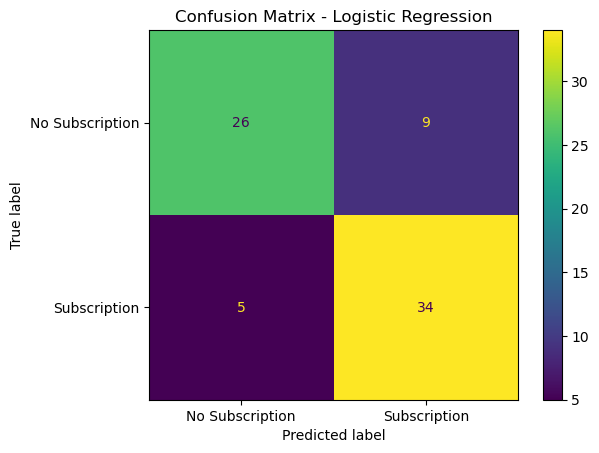

In [70]:
# Create a display object for the Logistic Regression confusion matrix
display_cm_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No Subscription", "Subscription"]
)

# Plot the Logistic Regression confusion matrix
display_cm_logistic.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [71]:
# Calculate evaluation metrics for Logistic Regression
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic, zero_division=0)
recall_logistic = recall_score(y_test, y_pred_logistic, zero_division=0)
f1_logistic = f1_score(y_test, y_pred_logistic, zero_division=0)

# Print Logistic Regression evaluation metrics
print("Logistic Regression Evaluation Metrics:")
print("Accuracy:", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall:", recall_logistic)
print("F1-score:", f1_logistic)

Logistic Regression Evaluation Metrics:
Accuracy: 0.8108108108108109
Precision: 0.7906976744186046
Recall: 0.8717948717948718
F1-score: 0.8292682926829268


In [72]:
# Print the classification report for Logistic Regression
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_logistic, target_names=["No Subscription", "Subscription"], zero_division=0))


Classification Report - Logistic Regression:
                 precision    recall  f1-score   support

No Subscription       0.84      0.74      0.79        35
   Subscription       0.79      0.87      0.83        39

       accuracy                           0.81        74
      macro avg       0.81      0.81      0.81        74
   weighted avg       0.81      0.81      0.81        74



In [73]:
# Import Support Vector Classifier from scikit-learn
from sklearn.svm import SVC

# Create an SVM classification model
# probability=True allows us to calculate prediction probabilities later if needed.
svm_model = SVC(random_state=42, probability=True)

# Train the SVM model using the preprocessed training data
svm_model.fit(X_train_preprocessed, y_train)

# Print a success message after training
print("SVM model trained successfully!")


SVM model trained successfully!


In [74]:
# Use the trained SVM model to predict values for the test data
y_pred_svm = svm_model.predict(X_test_preprocessed)

# Print a success message after prediction
print("SVM predictions completed successfully!")

# Display the first 10 predictions
print("\nFirst 10 SVM predictions:")
print(y_pred_svm[:10])


SVM predictions completed successfully!

First 10 SVM predictions:
[1 0 1 0 1 0 1 1 1 0]


In [75]:
# Create a DataFrame to compare actual and predicted values
svm_comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "SVM_Predicted": y_pred_svm
})

# Convert numeric labels into readable labels
svm_comparison_df["Actual_Label"] = svm_comparison_df["Actual"].map({0: "No Subscription", 1: "Subscription"})
svm_comparison_df["Predicted_Label"] = svm_comparison_df["SVM_Predicted"].map({0: "No Subscription", 1: "Subscription"})

# Display the first 10 actual and predicted values
display(svm_comparison_df.head(10))


,Actual,SVM_Predicted,Actual_Label,Predicted_Label
0,1,1,Subscription,Subscription
1,0,0,No Subscription,No Subscription
2,1,1,Subscription,Subscription
3,0,0,No Subscription,No Subscription
4,1,1,Subscription,Subscription
5,0,0,No Subscription,No Subscription
6,1,1,Subscription,Subscription
7,1,1,Subscription,Subscription
8,1,1,Subscription,Subscription
9,0,0,No Subscription,No Subscription


In [76]:
# Calculate the confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Print the confusion matrix as numbers
print("Confusion Matrix - SVM:")
print(cm_svm)


Confusion Matrix - SVM:
[[25 10]
 [ 5 34]]


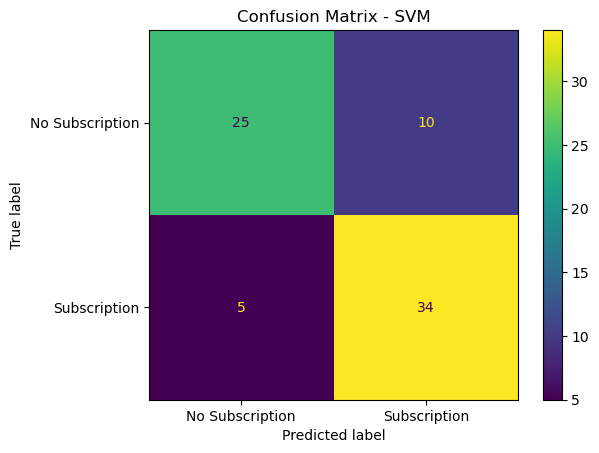

In [77]:
# Create a display object for the SVM confusion matrix
display_cm_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No Subscription", "Subscription"]
)

# Plot the SVM confusion matrix
display_cm_svm.plot()
plt.title("Confusion Matrix - SVM")
plt.show()


In [78]:
# Calculate evaluation metrics for SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)

# Print SVM evaluation metrics
print("SVM Evaluation Metrics:")
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1-score:", f1_svm)


SVM Evaluation Metrics:
Accuracy: 0.7972972972972973
Precision: 0.7727272727272727
Recall: 0.8717948717948718
F1-score: 0.8192771084337349


In [79]:
# Print the classification report for SVM
print("Classification Report - SVM:")
print(classification_report(y_test, y_pred_svm, target_names=["No Subscription", "Subscription"], zero_division=0))


Classification Report - SVM:
                 precision    recall  f1-score   support

No Subscription       0.83      0.71      0.77        35
   Subscription       0.77      0.87      0.82        39

       accuracy                           0.80        74
      macro avg       0.80      0.79      0.79        74
   weighted avg       0.80      0.80      0.80        74



In [80]:
# Create a comparison DataFrame for both models
model_comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],
    "Accuracy": [accuracy_logistic, accuracy_svm],
    "Precision": [precision_logistic, precision_svm],
    "Recall": [recall_logistic, recall_svm],
    "F1-score": [f1_logistic, f1_svm]
})

# Round the metric values for easier reading
model_comparison_df[["Accuracy", "Precision", "Recall", "F1-score"]] = model_comparison_df[["Accuracy", "Precision", "Recall", "F1-score"]].round(4)

# Display the model comparison table
display(model_comparison_df)


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8108,0.7907,0.8718,0.8293
1,SVM,0.7973,0.7727,0.8718,0.8193


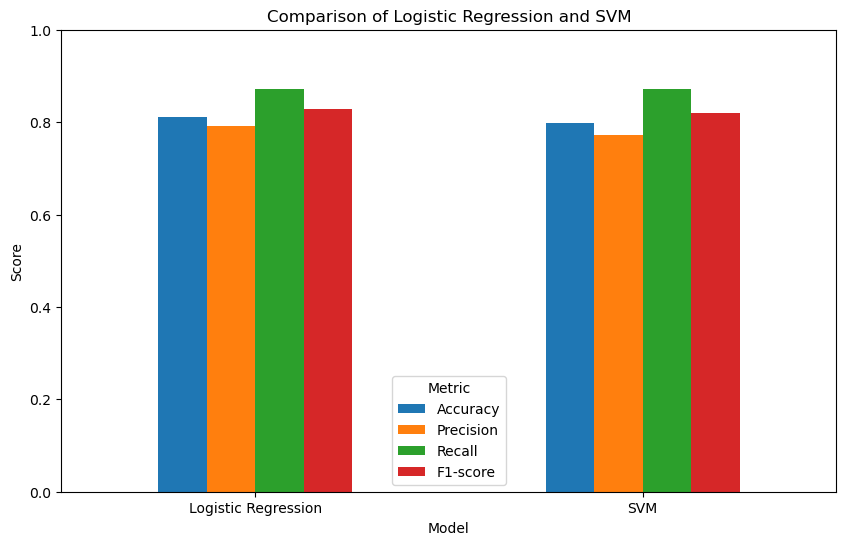

In [81]:
# Create a bar chart comparing the model metrics
model_comparison_df.set_index("Model").plot(kind="bar", figsize=(10, 6))

# Add a title and labels to the chart
plt.title("Comparison of Logistic Regression and SVM")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()


In [82]:
# Identify which model has the better F1-score
best_model_by_f1 = model_comparison_df.sort_values(by="F1-score", ascending=False).iloc[0]

# Print the best model based on F1-score
print("Best model based on F1-score:")
print(best_model_by_f1["Model"])

print("\nF1-score:")
print(best_model_by_f1["F1-score"])


Best model based on F1-score:
Logistic Regression

F1-score:
0.8293


In [83]:
# Use Logistic Regression to calculate prediction probabilities
logistic_probabilities = logistic_model.predict_proba(X_test_preprocessed)

# The first column is the probability of class 0: No Subscription
prob_no_subscription = logistic_probabilities[:, 0]

# The second column is the probability of class 1: Subscription
prob_subscription = logistic_probabilities[:, 1]

# Create a DataFrame to show actual values, predictions, and probabilities
classification_output_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logistic,
    "Probability_No_Subscription": prob_no_subscription.round(3),
    "Probability_Subscription": prob_subscription.round(3)
})

# Convert numeric labels into readable labels
classification_output_df["Actual_Label"] = classification_output_df["Actual"].map({0: "No Subscription", 1: "Subscription"})
classification_output_df["Predicted_Label"] = classification_output_df["Predicted"].map({0: "No Subscription", 1: "Subscription"})

# Display the first 15 rows of the classification output table
display(classification_output_df.head(15))


,Actual,Predicted,Probability_No_Subscription,Probability_Subscription,Actual_Label,Predicted_Label
0,1,1,0.002,0.998,Subscription,Subscription
1,0,0,0.735,0.265,No Subscription,No Subscription
2,1,1,0.013,0.987,Subscription,Subscription
3,0,0,0.977,0.023,No Subscription,No Subscription
4,1,1,0.087,0.913,Subscription,Subscription
5,0,0,0.870,0.130,No Subscription,No Subscription
6,1,1,0.111,0.889,Subscription,Subscription
7,1,1,0.086,0.914,Subscription,Subscription
8,1,1,0.450,0.550,Subscription,Subscription
9,0,1,0.445,0.555,No Subscription,Subscription


In [84]:
# Create a simple explanation for each prediction based on the 0.50 threshold
classification_output_df["Decision_Explanation"] = classification_output_df["Probability_Subscription"].apply(
    lambda p: "Predicted Subscription because probability is 0.50 or higher" if p >= 0.50 else "Predicted No Subscription because probability is below 0.50"
)

# Display the first 15 rows with decision explanations
display(classification_output_df.head(15))


,Actual,Predicted,Probability_No_Subscription,Probability_Subscription,Actual_Label,Predicted_Label,Decision_Explanation
0,1,1,0.002,0.998,Subscription,Subscription,Predicted Subscription because probability is ...
1,0,0,0.735,0.265,No Subscription,No Subscription,Predicted No Subscription because probability ...
2,1,1,0.013,0.987,Subscription,Subscription,Predicted Subscription because probability is ...
3,0,0,0.977,0.023,No Subscription,No Subscription,Predicted No Subscription because probability ...
4,1,1,0.087,0.913,Subscription,Subscription,Predicted Subscription because probability is ...
5,0,0,0.870,0.130,No Subscription,No Subscription,Predicted No Subscription because probability ...
6,1,1,0.111,0.889,Subscription,Subscription,Predicted Subscription because probability is ...
7,1,1,0.086,0.914,Subscription,Subscription,Predicted Subscription because probability is ...
8,1,1,0.450,0.550,Subscription,Subscription,Predicted Subscription because probability is ...
9,0,1,0.445,0.555,No Subscription,Subscription,Predicted Subscription because probability is ...


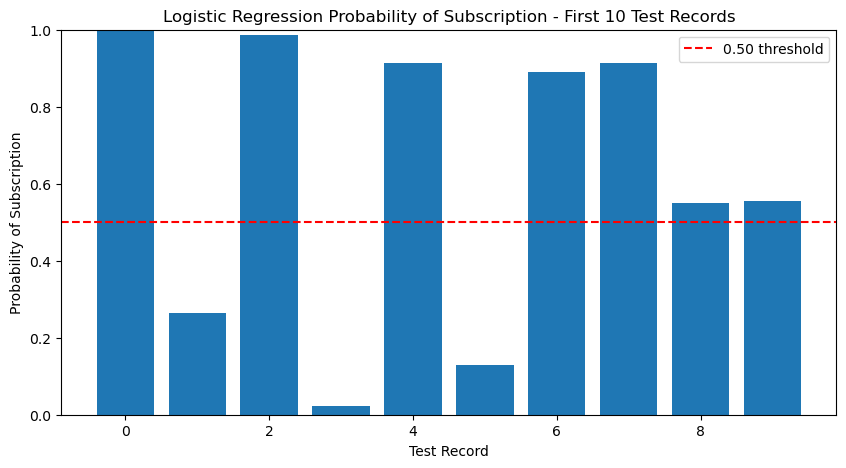

In [85]:
# Select the first 10 outputs for a simple probability chart
first_10_outputs = classification_output_df.head(10)

# Create a bar chart for the probability of subscription
plt.figure(figsize=(10, 5))
plt.bar(range(len(first_10_outputs)), first_10_outputs["Probability_Subscription"])
plt.axhline(y=0.50, color="red", linestyle="--", label="0.50 threshold")
plt.title("Logistic Regression Probability of Subscription - First 10 Test Records")
plt.xlabel("Test Record")
plt.ylabel("Probability of Subscription")
plt.ylim(0, 1)
plt.legend()
plt.show()


In [ ]:
## Which model performed better?
The better model is the one with stronger evaluation metrics, especially F1-score and recall. The notebook calculates both models and identifies the model with the higher F1-score in the comparison section.

## Which metric matters most for this business problem?
Recall and F1-score are very important for this business problem.
Recall is important because the business wants to identify customers who are likely to subscribe. If recall is low, the model may miss many customers who actually would subscribe.
F1-score is also important because it balances precision and recall.

## What do false positives mean in this dataset?
A false positive means the model predicted that a customer would subscribe, but the customer actually did not subscribe.
Business meaning: the company may spend time or marketing resources contacting a customer who is not interested.

## What do false negatives mean in this dataset?
A false negative means the model predicted that a customer would not subscribe, but the customer actually did subscribe.
Business meaning: the company may miss a customer who could have been a good investment product opportunity.

## What is one possible limitation or bias in your model?
One possible limitation of the model is that it may learn bias from the training data. If the dataset is incomplete or unbalanced, the model may not perform well on new real-world data.

## Why should human judgment still be used?
Human judgment should still be used because machine learning models can make mistakes and may not understand real-world context or ethical considerations. Humans can review the predictions and make better decisions in complex situations.
    